In [21]:
import os
import numpy as np
import xarray as xr
import geopandas as gpd

import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

In [22]:
MEV_dir = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','5_DOWN')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [23]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

In [24]:
lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'
Tr = [5,  10,  20,  50, 100, 200]

In [25]:
DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_IMERG_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_IM, lat2d_IM)
MEV_IM = DATA.Mev_s.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_CMORPH_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_CM, lat2d_CM = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_CM, lat2d_CM)
MEV_CM = DATA.Mev_s.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_MSWEP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_MS, lat2d_MS = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_MS, lat2d_MS)
MEV_MS = DATA.Mev_s.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_ERA5_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_ER, lat2d_ER = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_ER, lat2d_ER)
MEV_ER = DATA.Mev_s.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_GSMaP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_GS, lat2d_GS = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_GS, lat2d_GS)
MEV_GS = DATA.Mev_s.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_CHIRPS_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_CH, lat2d_CH = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_CH, lat2d_CH)
MEV_CH = DATA.Mev_s.where(mask_italy).values

MEV_CH = np.where(MEV_CH==0,np.nan,MEV_CH)

Return Time: 50 years
Export figure to: ../../figures/ALL/Quantiles_ALL_MEV_raw_50yrs.png


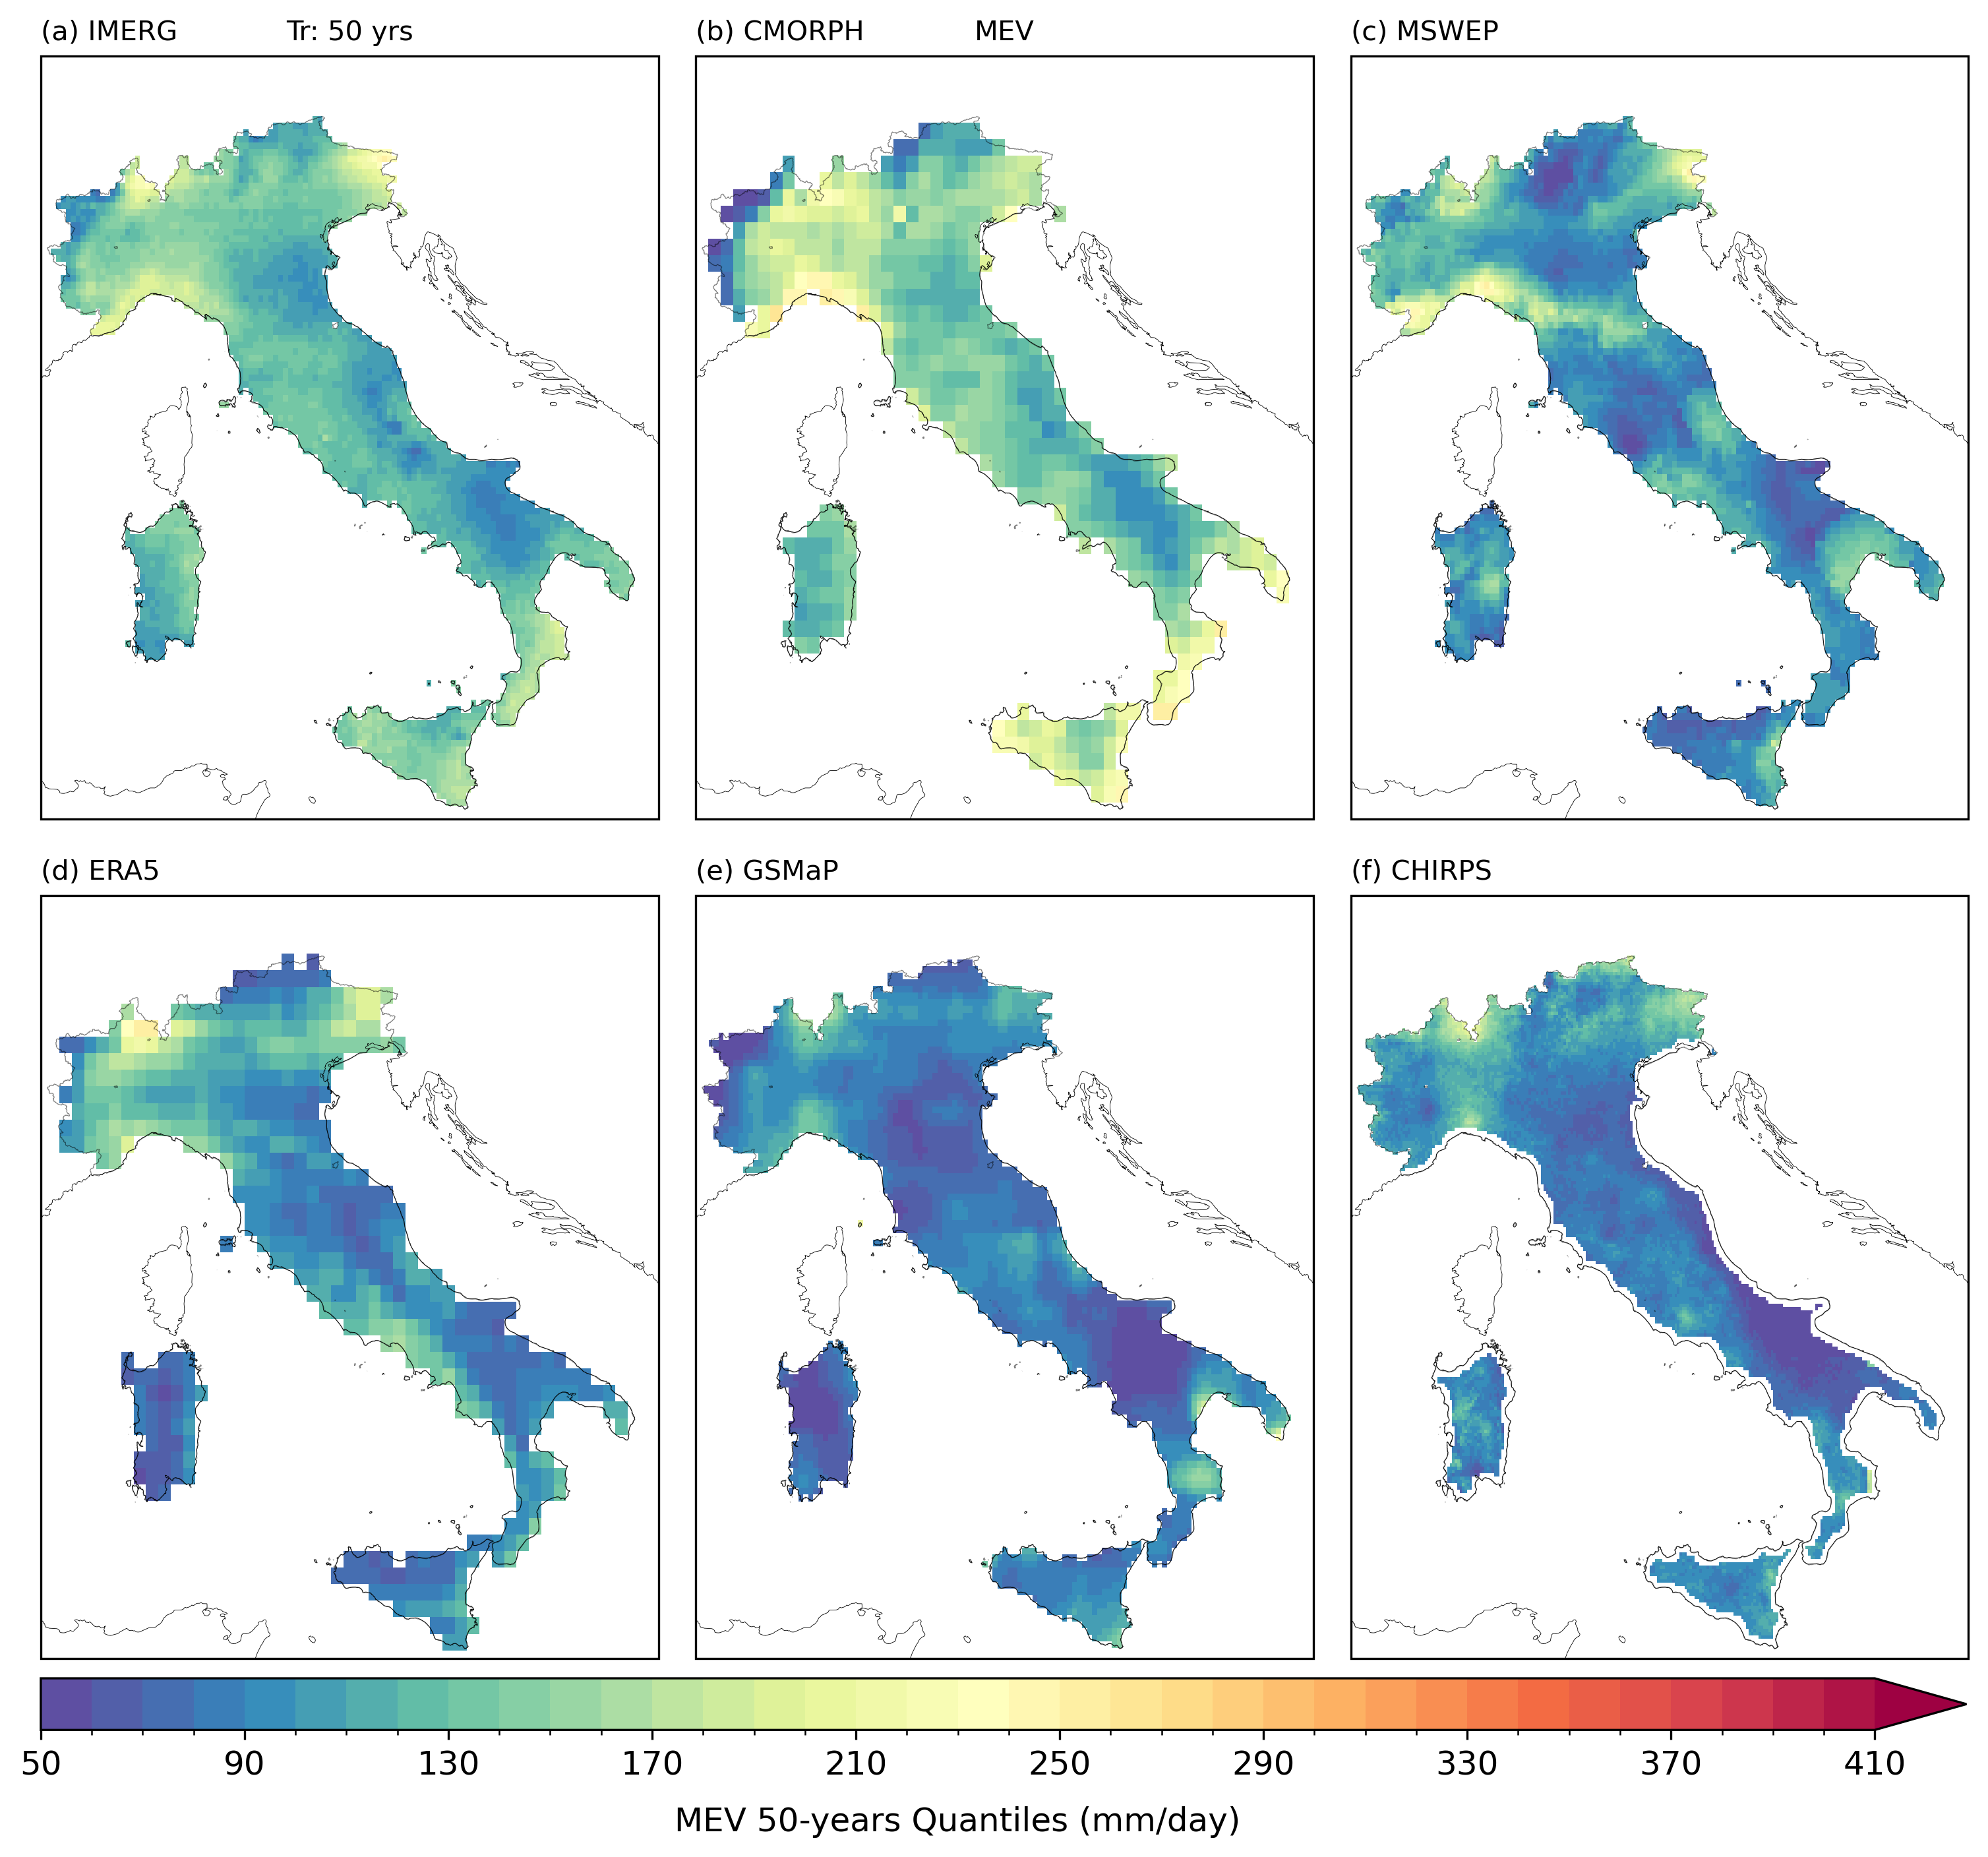

In [26]:
pos = 3
print(f'Return Time: {Tr[pos]} years')

Mev_levels = np.arange(50, 420, 10)
fonttitle = 10

Mev_cmap = plt.cm.Spectral_r
Mev_diff = plt.cm.coolwarm_r

norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N, extend='max')
# norm = None

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(11, 9), dpi=300)
gs = gridspec.GridSpec(2, 3)

axes = []
for nraw in range(2):
    for ncol in range(3):
        ax = fig.add_subplot(gs[nraw, ncol], projection=proj)
        # DEM.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.1, zorder=15, alpha=0.6)
        ITALY.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.3, zorder=21, alpha=0.5)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
        ax.coastlines(linewidth=0.2)
        axes.append(ax)

a1 = axes[0].pcolormesh(lon2d_IM, lat2d_IM, MEV_IM[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[0], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[1].pcolormesh(lon2d_CM, lat2d_CM, MEV_CM[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[1], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[2].pcolormesh(lon2d_MS, lat2d_MS, MEV_MS[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[2], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[3].pcolormesh(lon2d_ER, lat2d_ER, MEV_ER[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[3], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[4].pcolormesh(lon2d_GS, lat2d_GS, MEV_GS[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[4], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[5].pcolormesh(lon2d_CH, lat2d_CH, MEV_CH[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[5], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

axes[0].set_title('(a) IMERG', fontsize=fonttitle, loc='left')
axes[0].set_title(f'Tr: {Tr[pos]} yrs', fontsize=fonttitle, loc='center')

axes[1].set_title('(b) CMORPH', fontsize=fonttitle, loc='left')
axes[1].set_title(f'MEV', fontsize=fonttitle, loc='center')

axes[2].set_title('(c) MSWEP', fontsize=fonttitle, loc='left')

axes[3].set_title('(d) ERA5', fontsize=fonttitle, loc='left')

axes[4].set_title('(e) GSMaP', fontsize=fonttitle, loc='left')

axes[5].set_title('(f) CHIRPS', fontsize=fonttitle, loc='left')


cbar_ax = fig.add_axes([0.057, 0.01, 0.885, 0.029]) # Horizontal
cbar = fig.colorbar(a1, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=12)
cbar.set_label(f"MEV {Tr[pos]}-years Quantiles (mm/day)", fontsize=12, labelpad=9)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.01, hspace=0.1)

salida = os.path.join('..','..','figures','ALL',f'Quantiles_ALL_MEV_raw_{Tr[pos]}yrs.png')
print(f'Export figure to: {salida}')
plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)
